KK1 - André Sjödahl

Analys av dataset "Movies"
https://www.kaggle.com/datasets/abdallahwagih/movies

Datasetet innehåller information om filmer såsom språk, popularitet, budget och betyg. Varje rad representerar en film. Datan kommer från icke verifierbara källor men ska enligt datasetbeskrivningen vara "sammanställd från olika trovärdiga källor" för 3 år sedan. Syftet med analysen är att undersöka vilka faktorer som verkar påverka betyg och hur filmer skiljer sig mellan språk.

In [279]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [280]:
df = pd.read_csv("data/movies.csv")

Strukturen på datasetet.

In [281]:
df.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


Datasetet innehåller 4803 rader (filmer) och 24 kolumner.

In [282]:
df.shape

(4803, 24)

Info visar att många filmer saknar hemsida i datasetet men att de flesta filmer har övriga kolumner ifyllda.

In [283]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   str    
 3   homepage              1712 non-null   str    
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   str    
 6   original_language     4803 non-null   str    
 7   original_title        4803 non-null   str    
 8   overview              4800 non-null   str    
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   str    
 11  production_countries  4803 non-null   str    
 12  release_date          4802 non-null   str    
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages      4803 non-n

Describe visar t.ex medel spellängd & betyg och även att många filmer har få röster.

In [284]:
df.describe()

,index,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4803.000000,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2401.000000,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,1386.651002,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,1200.500000,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,2401.000000,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,3601.500000,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,4802.000000,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


isna().sum() visar att kolumnerna "budget, popularity, vote_average, vote_count" är kompletta, men "runtime" har 2 NaN som ska bort.

In [285]:
df.isna().sum()

index                      0
budget                     0
genres                    28
homepage                3091
id                         0
keywords                 412
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                      43
crew                       0
director                  30
dtype: int64

dropna() för att ta bort de 2 filmerna utan "runtime" och en len() efteråt för att visa att datasetet blev 2 rader mindre. (4803 -> 4801)

In [286]:
df = df.dropna(subset=["runtime"])
len(df)

4801

Filmer med färre än 100 röster filtreras bort eftersom deras betyg och popularitet riskerar att bli missvisande. Ett mycket lågt antal röster gör statistiken mindre tillförlitlig.

In [287]:
df = df[df["vote_count"] >= 100]
len(df)

3162

Histogrammet visar att de flesta filmer får betyg mellan 5 och 7. Extremt höga och extremt låga betyg är ovanliga, vilket tyder på att filmbetyg tenderar att samlas kring medelvärden.

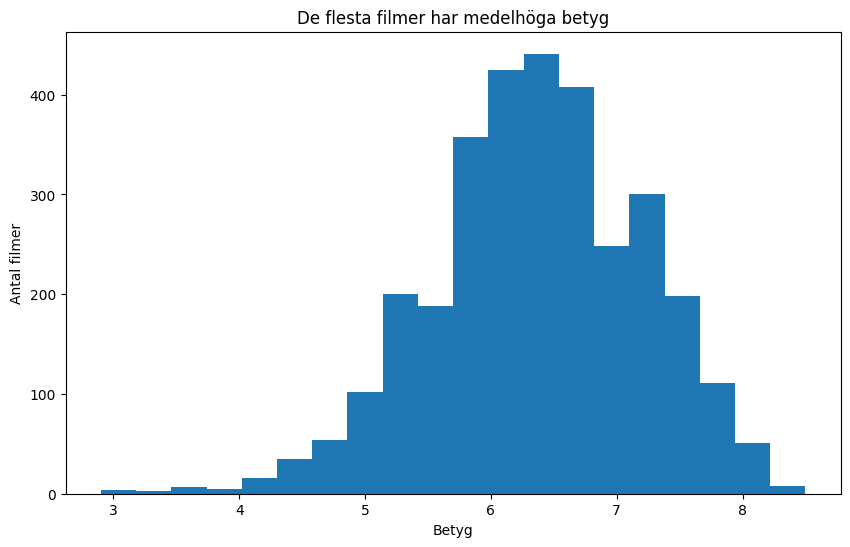

In [288]:
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(df["vote_average"], bins=20)

ax.set_title("De flesta filmer har medelhöga betyg")
ax.set_xlabel("Betyg")
ax.set_ylabel("Antal filmer")

plt.show()

Vilka språk har högst genomsnittligt betyg?

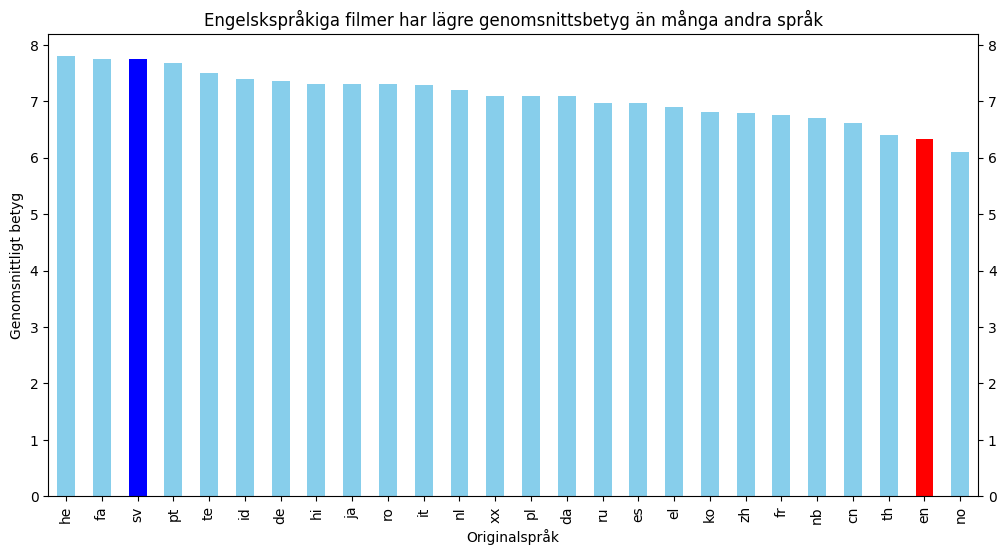

In [289]:
avg_rating = (
    df.groupby("original_language")["vote_average"]
    .mean()
    .sort_values(ascending=False)
)

# Skapar en lista "colors" med olika färgvärde per språk
colors = []
for lang in avg_rating.index:
    if lang == "en":
        colors.append("red")
    elif lang == "sv":
        colors.append("blue")
    else:
        colors.append("skyblue")

ax = avg_rating.plot(
    kind="bar",
    figsize=(12, 6),
    color=colors
)

ax.set_title("Engelskspråkiga filmer har lägre genomsnittsbetyg än många andra språk")
ax.set_xlabel("Originalspråk")
ax.set_ylabel("Genomsnittligt betyg")

# Visar även y-axel på höger sida
ax.yaxis.set_ticks_position("both")
ax.tick_params(axis="y", labelright=True)

plt.show()

Finns det samband mellan budget och betyg? 
(Testade hexbin men föredrog scatter som blev tydligare.)

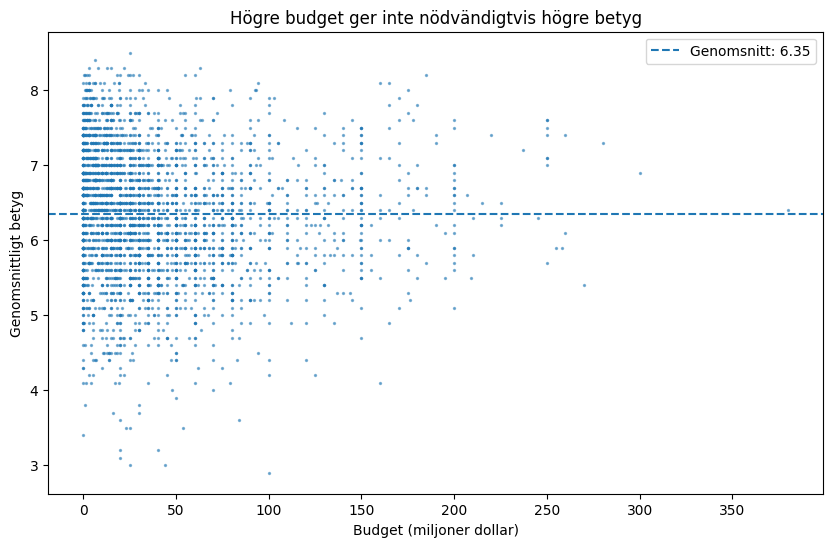

In [290]:
fig, ax = plt.subplots(figsize=(10, 6))
df_budget = df[df["budget"] > 0]

ax.scatter(
    df["budget"] / 1_000_000,
    df["vote_average"],
    alpha=0.5,
    s=2
)

ax.set_title("Högre budget ger inte nödvändigtvis högre betyg")
ax.set_xlabel("Budget (miljoner dollar)")
ax.set_ylabel("Genomsnittligt betyg")

average_rating = df["vote_average"].mean()

ax.axhline(average_rating, 
           linestyle="--",
           label=f"Genomsnitt: {average_rating:.2f}"
)

ax.legend()

plt.show()

Hur ser fördelningen av språk ut?

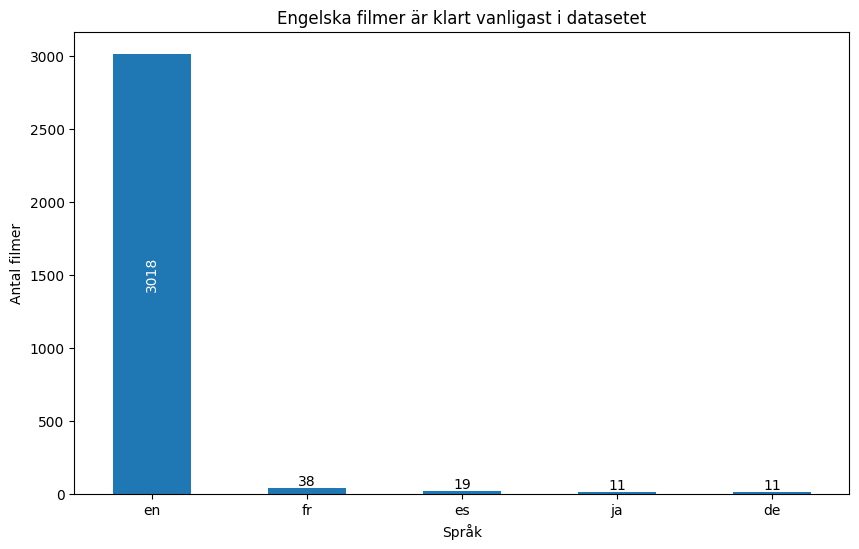

In [291]:
top_languages = df["original_language"].value_counts().head()

ax = top_languages.plot(kind="bar", figsize=(10, 6))

ax.set_title("Engelska filmer är klart vanligast i datasetet")
ax.set_xlabel("Språk")
ax.set_ylabel("Antal filmer")

# Text i första stapeln
bars = ax.patches
first_bar = bars[0]
first_height = first_bar.get_height()

ax.text(
    first_bar.get_x() + first_bar.get_width() / 2,
    first_height / 2,
    f"{first_height:.0f}",
    ha="center",
    va="center",
    rotation=90,
    color="white"
)

# Text ovanför resten av staplarna
for bar in bars[1:]:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        color="black"
    )

# Ändra x-axel till att visa labels horisontellt
ax.tick_params(axis="x", rotation=0)

plt.show()

Analysen visar att datasetet har för få filmer med annat språk än engelska för att man ska kunna dra bra slutsatser. Högre budget leder inte nödvändigtvis till högre betyg. Engelskspråkiga filmer har lägre genomsnittsbetyg än flera mindre språkgrupper i detta dataset.